# Datos Faltantes

In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [4]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
44,0.045341,0.050680,0.068163,0.008101,-0.016704,0.004636,-0.076536,0.071210,0.032432,-0.017646,259.0
214,0.030811,-0.044642,-0.033151,-0.022885,-0.046975,-0.081167,0.103865,-0.076395,-0.039809,-0.054925,65.0
40,0.005383,0.050680,-0.008362,0.021872,0.054845,0.073215,-0.024993,0.034309,0.012551,0.094191,100.0
191,-0.005515,0.050680,-0.041774,-0.043542,-0.079998,-0.076156,-0.032356,-0.039493,0.010227,-0.009362,178.0
341,0.030811,0.050680,0.059541,0.056301,-0.022208,0.001191,-0.032356,-0.002592,-0.024795,-0.017646,263.0
54,-0.049105,-0.044642,0.025051,0.008101,0.020446,0.017788,0.052322,-0.039493,-0.041176,0.007207,182.0
34,0.016281,-0.044642,-0.063330,-0.057313,-0.057983,-0.048912,0.008142,-0.039493,-0.059471,-0.067351,65.0
81,0.012648,0.050680,-0.022373,-0.029770,0.010815,0.028435,-0.021311,0.034309,-0.006081,-0.001078,51.0
59,0.063504,0.050680,-0.025607,0.011544,0.064477,0.048477,0.030232,-0.002592,0.038394,0.019633,170.0
244,-0.060003,0.050680,0.054152,-0.019442,-0.049727,-0.048912,0.022869,-0.039493,-0.043984,-0.005220,187.0


In [5]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [6]:
# Contar valores faltantes por columna
missing_summary = data.isnull().sum()
print("Conteo de valores faltantes:")
print(missing_summary[missing_summary > 0])

Conteo de valores faltantes:
bmi    44
bp     44
dtype: int64


### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [7]:
# Crear copia para imputación simple
data_simple = data.copy()

# Configurar e aplicar el imputador
simple_imputer = SimpleImputer(strategy='mean')
data_simple['bmi'] = simple_imputer.fit_transform(data_simple[['bmi']])

print(f"Nulos en 'bmi' tras imputación simple: {data_simple['bmi'].isnull().sum()}")

Nulos en 'bmi' tras imputación simple: 0


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [8]:
# Crear copia para KNN
data_knn = data.copy()

# Aplicar KNNImputer en bmi y bp (usando 5 vecinos por defecto)
knn_imp = KNNImputer(n_neighbors=5)
data_knn[['bmi', 'bp']] = knn_imp.fit_transform(data_knn[['bmi', 'bp']])

# Comparación de estadísticas para 'bmi'
print("--- Comparación de Estadísticas (bmi) ---")
print(f"Original (con nulos) Media: {data['bmi'].mean():.6f}")
print(f"Imputación Media:         {data_simple['bmi'].mean():.6f}")
print(f"Imputación KNN:           {data_knn['bmi'].mean():.6f}")

--- Comparación de Estadísticas (bmi) ---
Original (con nulos) Media: -0.000205
Imputación Media:         -0.000205
Imputación KNN:           0.000112


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

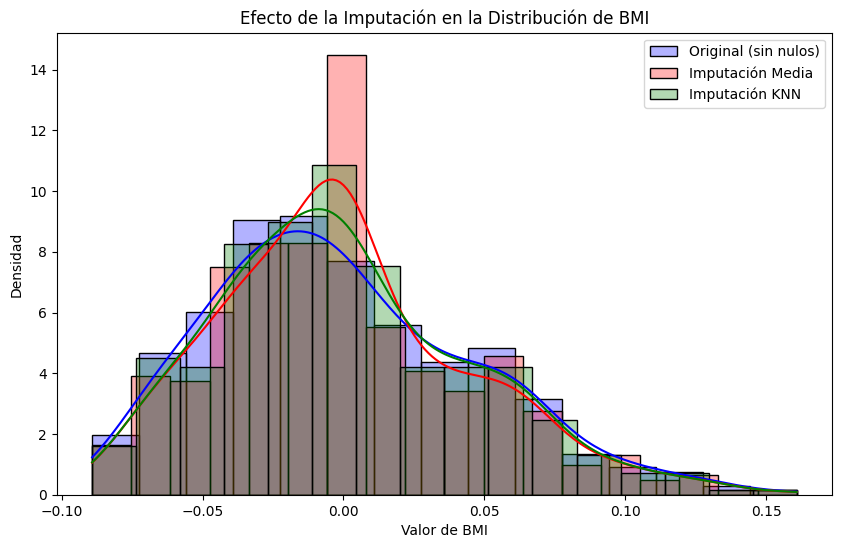

In [9]:
plt.figure(figsize=(10, 6))

# Histograma de datos originales (eliminando nulos para la visualización)
sns.histplot(data['bmi'].dropna(), color="blue", label="Original (sin nulos)", kde=True, stat="density", alpha=0.3)

# Histograma tras imputación simple
sns.histplot(data_simple['bmi'], color="red", label="Imputación Media", kde=True, stat="density", alpha=0.3)

# Histograma tras imputación KNN
sns.histplot(data_knn['bmi'], color="green", label="Imputación KNN", kde=True, stat="density", alpha=0.3)

plt.title("Efecto de la Imputación en la Distribución de BMI")
plt.xlabel("Valor de BMI")
plt.ylabel("Densidad")
plt.legend()
plt.show()